# Import

In [81]:
import cv2
import skimage.io
import skimage.metrics
import skimage as ski
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Reading images

In [82]:
# For the experiment purpose, I will put the Google Drive paths directly.
Ker = ski.util.img_as_ubyte(ski.io.imread("/content/drive/MyDrive/research/ML-OCT_datasets/OCT2017/train/DME/DME-1072015-2.jpeg", as_gray=True))
ID = ski.util.img_as_ubyte(ski.io.imread("/content/drive/MyDrive/research/ML-OCT_datasets/108503-V1/Diabetic-Retinopathy-Retinal-OCT-Images/OCTID_DR/DR1.jpeg", as_gray=True))
DL = ski.util.img_as_ubyte(ski.io.imread("/content/drive/MyDrive/research/ML-OCT_datasets/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/DME/dme_1057060_1.jpg", as_gray=True))

#image chosen arbitrarily

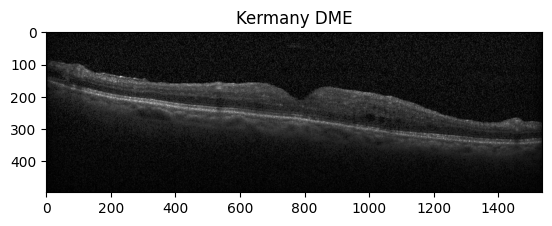

In [89]:
plt.imshow(Ker,cmap="gray")

# PSNR

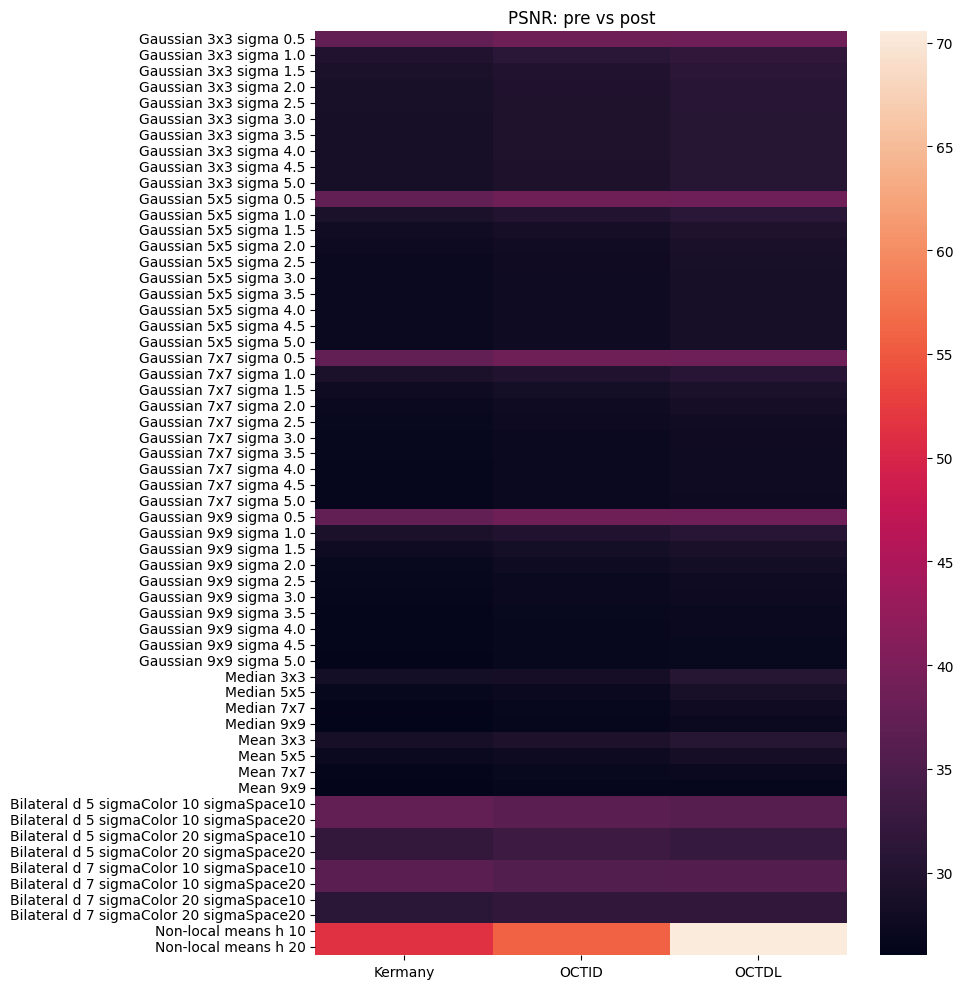

In [91]:
sns.heatmap(psnrs, xticklabels = datasets, yticklabels= denoise_techniques)
plt.title("PSNR")
plt.tight_layout()
plt.show()

# Adding noise

## Define function

In [124]:
def compare_psnrs(noise_mean, noise_var, kernel_sizes, Gaus_filter_sigmas, bil_ds, bil_sigmas_color, bil_sigmas_space, nonl_hs):
  # Add noise

  Ker_speckle = ski.util.img_as_ubyte(ski.util.random_noise(Ker, mode="speckle",mean =noise_mean, var=noise_var))
  ID_speckle = ski.util.img_as_ubyte(ski.util.random_noise(ID, mode="speckle",mean =noise_mean, var=noise_var))
  DL_speckle = ski.util.img_as_ubyte(ski.util.random_noise(DL, mode="speckle",mean =noise_mean, var=noise_var))
  # visualise the images

  # plt.subplot(211)
  # plt.imshow(Ker,cmap="gray")
  # plt.title("Kermany: original")

  # plt.subplot(212)
  # plt.imshow(Ker_speckle,cmap="gray")
  # plt.title("noise added")

  # plt.tight_layout()
  # plt.show()
  #sum of all the denoising techniques:4x4 +4+4 +8 +2
  no_filterings = len(kernel_sizes)*len(Gaus_filter_sigmas)+len(kernel_sizes)*2+len(bil_ds)*len(bil_sigmas_color)*len(bil_sigmas_space)+len(nonl_hs)
  psnrs = np.zeros((no_filterings,3))
  denoise_techniques = []


  images = [Ker, ID, DL]
  images_speckle = [Ker_speckle,ID_speckle,DL_speckle]
  for i in range(len(images)):

    #Gaussian
    sigmas = Gaus_filter_sigmas

    count = 0
    for k in kernel_sizes:
      for s in sigmas:
        # print("kernel {} sigma {}".format(k,s))
        # print("images speckle")
        # print(images_speckle[i].shape)
        # print(images_speckle[i].dtype)
        # print("ogirinal images")
        # print(images[i].shape)
        # print(images[i].dtype)

        Gaus = cv2.GaussianBlur(images_speckle[i],(k,k),s)
        # print("after Gaussian")
        # print(Gaus.shape)
        # print(Gaus.dtype)


        # plt.imshow(images[i],cmap="gray")
        # plt.title("original")
        # plt.show()


        # plt.imshow(images_speckle[i],cmap="gray")
        # plt.title("noise added")
        # plt.show()


        # plt.imshow(Gaus,cmap="gray")
        # plt.title("filtered")
        # plt.show()


        psnr = cv2.PSNR(images[i], Gaus)

        #psnr_ski_ID = skimage.metrics.peak_signal_noise_ratio(ID, Gaus_ID)

        #print(psnr_ID)
        psnrs[count,i] = psnr
        count +=1
        if i==0:
          denoise_techniques.append("Gaussian {}x{} sigma {}".format(k,k,s))

    #Median filtering
    for k in kernel_sizes:
      med = cv2.medianBlur(images_speckle[i],k)
      psnr = cv2.PSNR(images[i],med)
      psnrs[count,i] = psnr
      count +=1

      if i ==0:
        denoise_techniques.append("Median {}x{}".format(k,k))

    #Mean filtering
    for k in kernel_sizes:
      mean = cv2.blur(images_speckle[i],(k,k))
      psnr = cv2.PSNR(images[i],mean)
      psnrs[count,i] = psnr
      count +=1

      if i ==0:
        denoise_techniques.append("Mean {}x{}".format(k,k))

    #Bilateral
    ds = bil_ds
    sigmas_color = bil_sigmas_color
    sigmas_space = bil_sigmas_space

    for d in ds:
      for sc in sigmas_color:
        for ss in sigmas_color:
          bilateral = cv2.bilateralFilter(images_speckle[i],d,sc,ss)
          psnr = cv2.PSNR(images[i],bilateral)
          psnrs[count,i] = psnr
          count+=1

          if i ==0:
            denoise_techniques.append("Bilateral d {} sigmaColor {} sigmaSpace{}".format(d,sc,ss))

    #Non local means
    hs = nonl_hs

    for h in hs:
      nl =cv2.fastNlMeansDenoising(images_speckle[i],h) #search window and block size are default size? #should I vary them as well?
      psnr =cv2.PSNR(images[i],nl)
      psnrs[count,i] = psnr
      count+=1

      if i ==0:
        denoise_techniques.append("Non-local means h {}".format(h))



  #print(psnrs)
  #print(denoise_techniques)
  datasets = ["Kermany","OCTID","OCTDL"]
  plt.figure(figsize=(10, 10))
  sns.heatmap(psnrs, xticklabels = datasets, yticklabels= denoise_techniques)
  plt.title("PSNR: original vs noise>denoised, speckle mean {} var {}".format(noise_mean, noise_var))
  plt.tight_layout()
  plt.show()

  plt.figure(figsize=(10, 10))
  plt.scatter(denoise_techniques, psnrs[:,0], label = 'Kermany')
  plt.scatter(denoise_techniques, psnrs[:,1], label = 'OCTID')
  plt.scatter(denoise_techniques, psnrs[:,2], label = 'OCTDL')
  plt.xlabel('Denoising techniques')
  plt.xticks(rotation = 90)
  plt.ylabel('PSNR')
  plt.legend()
  plt.title('PSNR: original vs noise>denoised, speckle mean {} var {}'.format(noise_mean, noise_var))
  return

## Calculate

In [125]:
kernel_sizes = [3,5,7,9]
sigmas = [0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0]
ds = [5,7]
sigmas_color = [10,20]
sigmas_space = [10,20]
hs = [10,20]

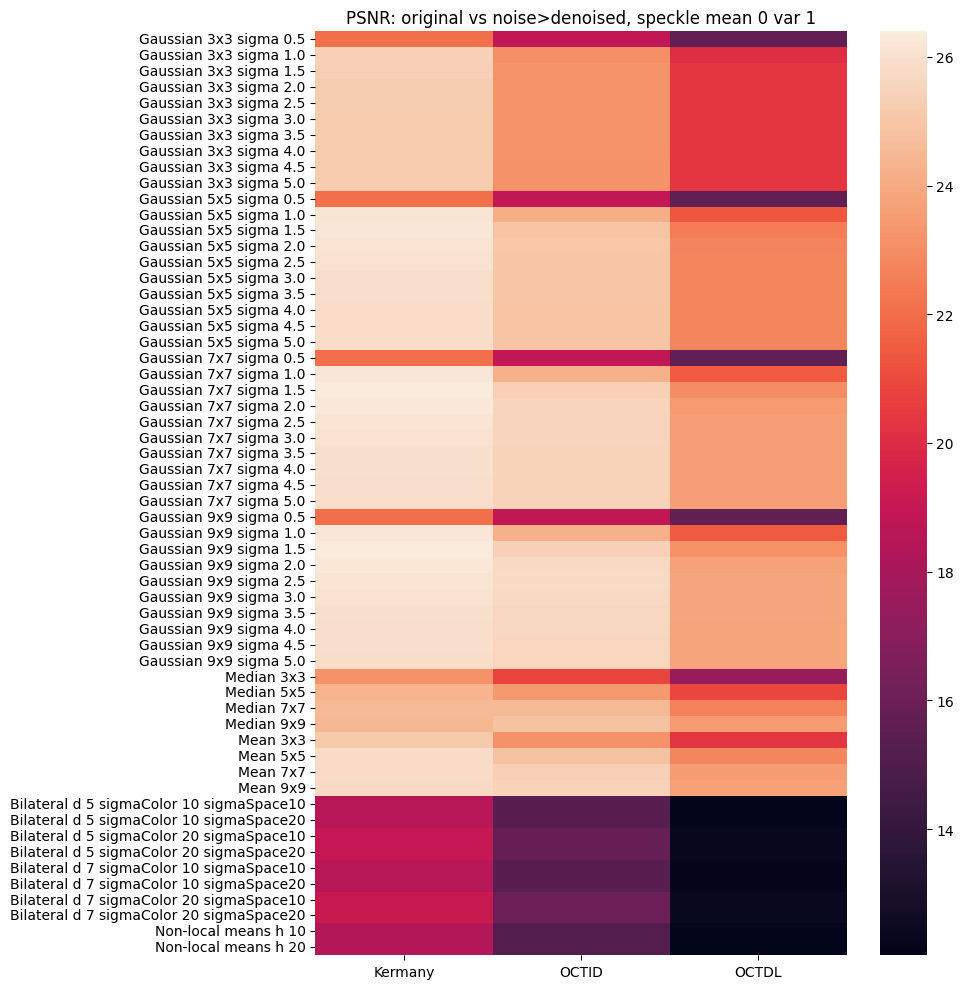

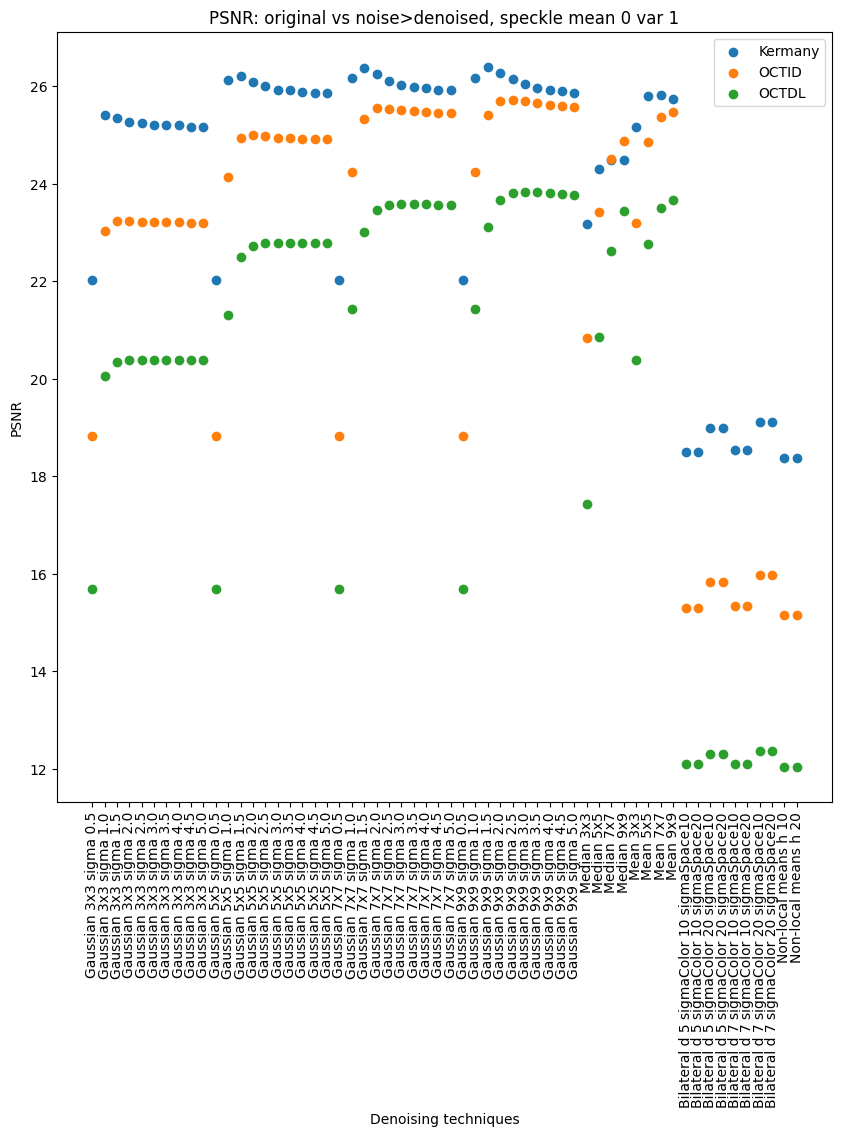

In [126]:
compare_psnrs(0,1,kernel_sizes,sigmas,ds,sigmas_color,sigmas_space,hs)

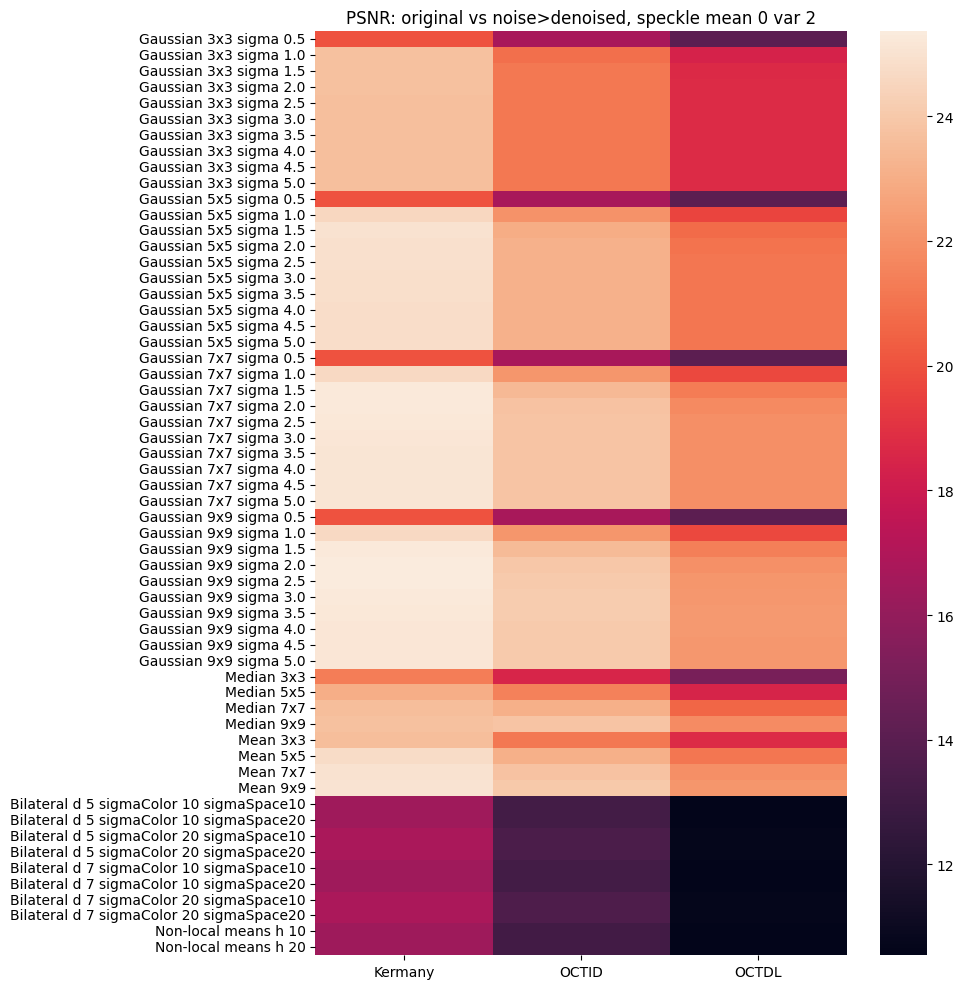

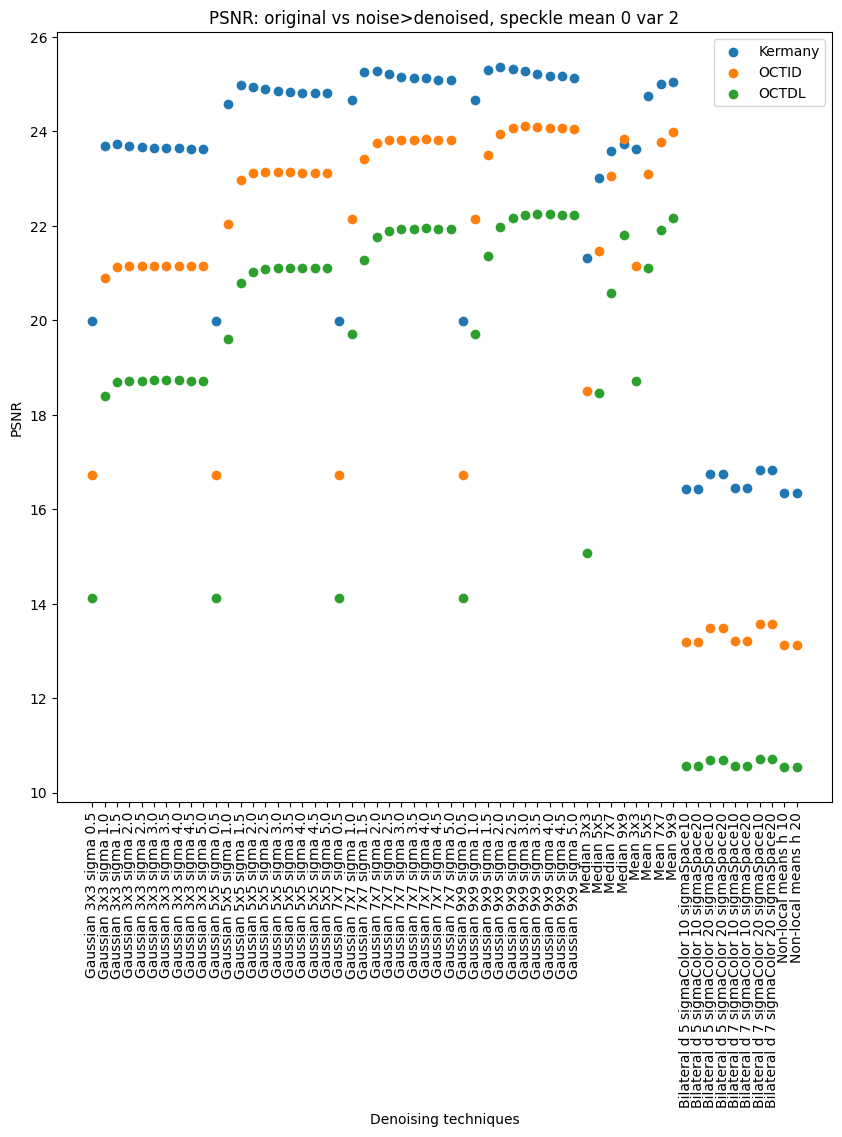

In [127]:
compare_psnrs(0,2,kernel_sizes,sigmas,ds,sigmas_color,sigmas_space,hs)

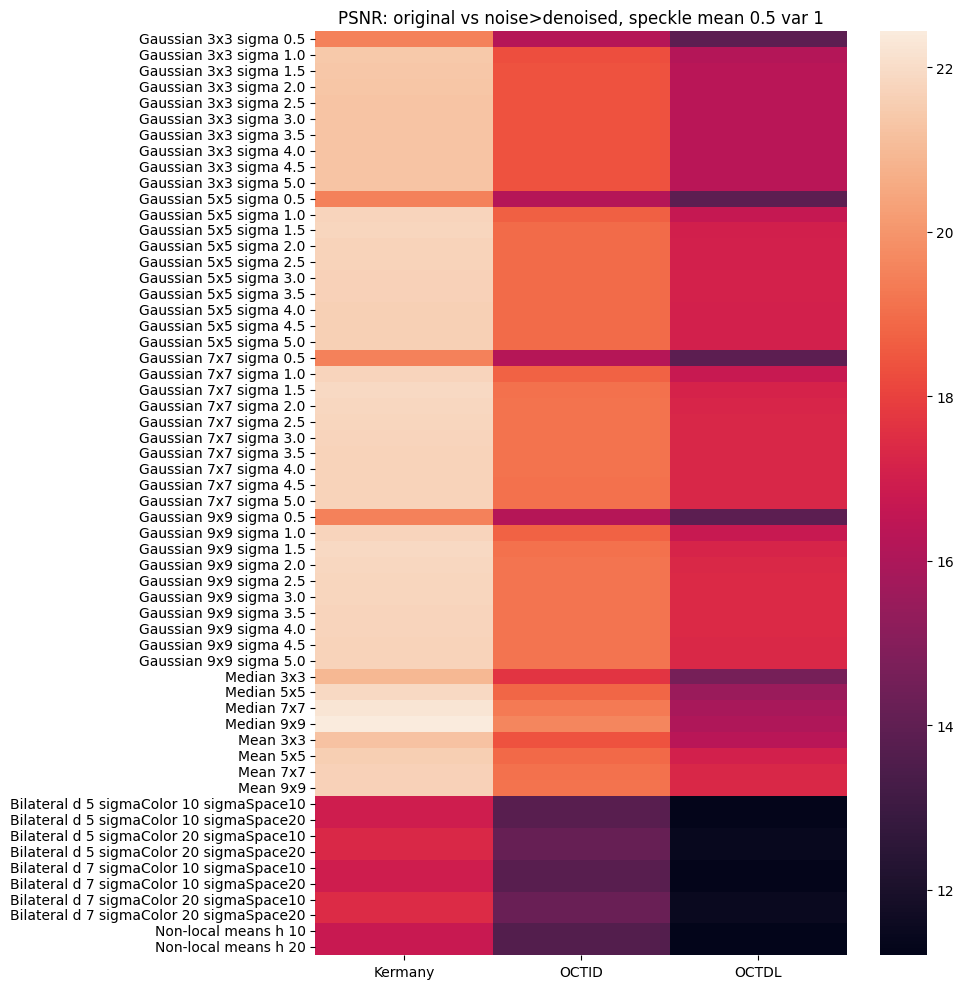

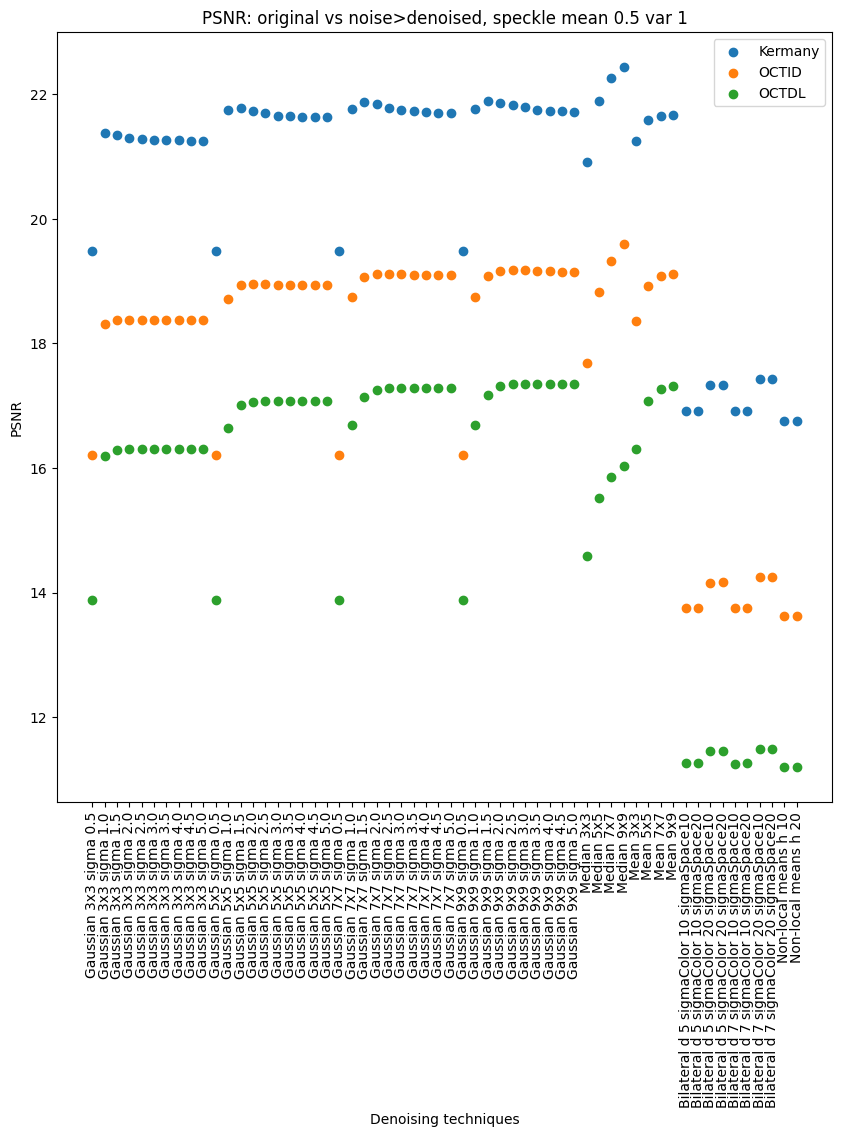

In [130]:
compare_psnrs(0.5,1,kernel_sizes,sigmas,ds,sigmas_color,sigmas_space,hs)

# SSIM

In [128]:
# Compute SSIM
def compare_ssims(noise_mean, noise_var, kernel_sizes, Gaus_filter_sigmas, bil_ds, bil_sigmas_color, bil_sigmas_space, nonl_hs):
  # Add noise

  Ker_speckle = ski.util.img_as_ubyte(ski.util.random_noise(Ker, mode="speckle",mean =noise_mean, var=noise_var))
  ID_speckle = ski.util.img_as_ubyte(ski.util.random_noise(ID, mode="speckle",mean =noise_mean, var=noise_var))
  DL_speckle = ski.util.img_as_ubyte(ski.util.random_noise(DL, mode="speckle",mean =noise_mean, var=noise_var))
  # visualise the images

  # plt.subplot(211)
  # plt.imshow(Ker,cmap="gray")
  # plt.title("Kermany: original")

  # plt.subplot(212)
  # plt.imshow(Ker_speckle,cmap="gray")
  # plt.title("noise added")

  # plt.tight_layout()
  # plt.show()
  #sum of all the denoising techniques:4x4 +4+4 +8 +2
  no_filterings = len(kernel_sizes)*len(Gaus_filter_sigmas)+len(kernel_sizes)*2+len(bil_ds)*len(bil_sigmas_color)*len(bil_sigmas_space)+len(nonl_hs)
  ssims = np.zeros((no_filterings,3))
  denoise_techniques = []


  images = [Ker, ID, DL]
  images_speckle = [Ker_speckle,ID_speckle,DL_speckle]
  for i in range(len(images)):

    #Gaussian
    sigmas = Gaus_filter_sigmas

    count = 0
    for k in kernel_sizes:
      for s in sigmas:

        Gaus = cv2.GaussianBlur(images_speckle[i],(k,k),s)
        # print("after Gaussian")
        # print(Gaus.shape)
        # print(Gaus.dtype)


        # plt.imshow(images[i],cmap="gray")
        # plt.title("original")
        # plt.show()


        # plt.imshow(images_speckle[i],cmap="gray")
        # plt.title("noise added")
        # plt.show()


        # plt.imshow(Gaus,cmap="gray")
        # plt.title("filtered")
        # plt.show()


        ssim = ski.metrics.structural_similarity(images[i], Gaus)

        #psnr_ski_ID = skimage.metrics.peak_signal_noise_ratio(ID, Gaus_ID)

        #print(psnr_ID)
        ssims[count,i] = ssim
        count +=1
        if i==0:
          denoise_techniques.append("Gaussian {}x{} sigma {}".format(k,k,s))

    #Median filtering
    for k in kernel_sizes:
      med = cv2.medianBlur(images_speckle[i],k)
      ssim = ski.metrics.structural_similarity(images[i],med)
      ssims[count,i] = ssim
      count +=1

      if i ==0:
        denoise_techniques.append("Median {}x{}".format(k,k))

    #Mean filtering
    for k in kernel_sizes:
      mean = cv2.blur(images_speckle[i],(k,k))
      ssim = ski.metrics.structural_similarity(images[i],mean)
      ssims[count,i] = ssim
      count +=1

      if i ==0:
        denoise_techniques.append("Mean {}x{}".format(k,k))

    #Bilateral
    ds = bil_ds
    sigmas_color = bil_sigmas_color
    sigmas_space = bil_sigmas_space

    for d in ds:
      for sc in sigmas_color:
        for ss in sigmas_color:
          bilateral = cv2.bilateralFilter(images_speckle[i],d,sc,ss)
          ssim = ski.metrics.structural_similarity(images[i],bilateral)
          ssims[count,i] = ssim
          count+=1

          if i ==0:
            denoise_techniques.append("Bilateral d {} sigmaColor {} sigmaSpace{}".format(d,sc,ss))

    #Non local means
    hs = nonl_hs

    for h in hs:
      nl =cv2.fastNlMeansDenoising(images_speckle[i],h) #search window and block size are default size? #should I vary them as well?
      ssim =ski.metrics.structural_similarity(images[i],nl)
      ssims[count,i] = ssim
      count+=1

      if i ==0:
        denoise_techniques.append("Non-local means h {}".format(h))



  #print(ssims)
  #print(denoise_techniques)
  datasets = ["Kermany","OCTID","OCTDL"]
  plt.figure(figsize=(10, 10))
  sns.heatmap(ssims, xticklabels = datasets, yticklabels= denoise_techniques)
  plt.title("SSIM: original vs noise>denoised, speckle mean {} var {}".format(noise_mean, noise_var))
  plt.tight_layout()
  plt.show()

  plt.figure(figsize=(10, 10))
  plt.scatter(denoise_techniques, ssims[:,0], label = 'Kermany')
  plt.scatter(denoise_techniques, ssims[:,1], label = 'OCTID')
  plt.scatter(denoise_techniques, ssims[:,2], label = 'OCTDL')
  plt.xlabel('Denoising techniques')
  plt.xticks(rotation = 90)
  plt.ylabel('SSIM')
  plt.legend()
  plt.title('SSIM: original vs noise>denoised, speckle mean {} var {}'.format(noise_mean, noise_var))

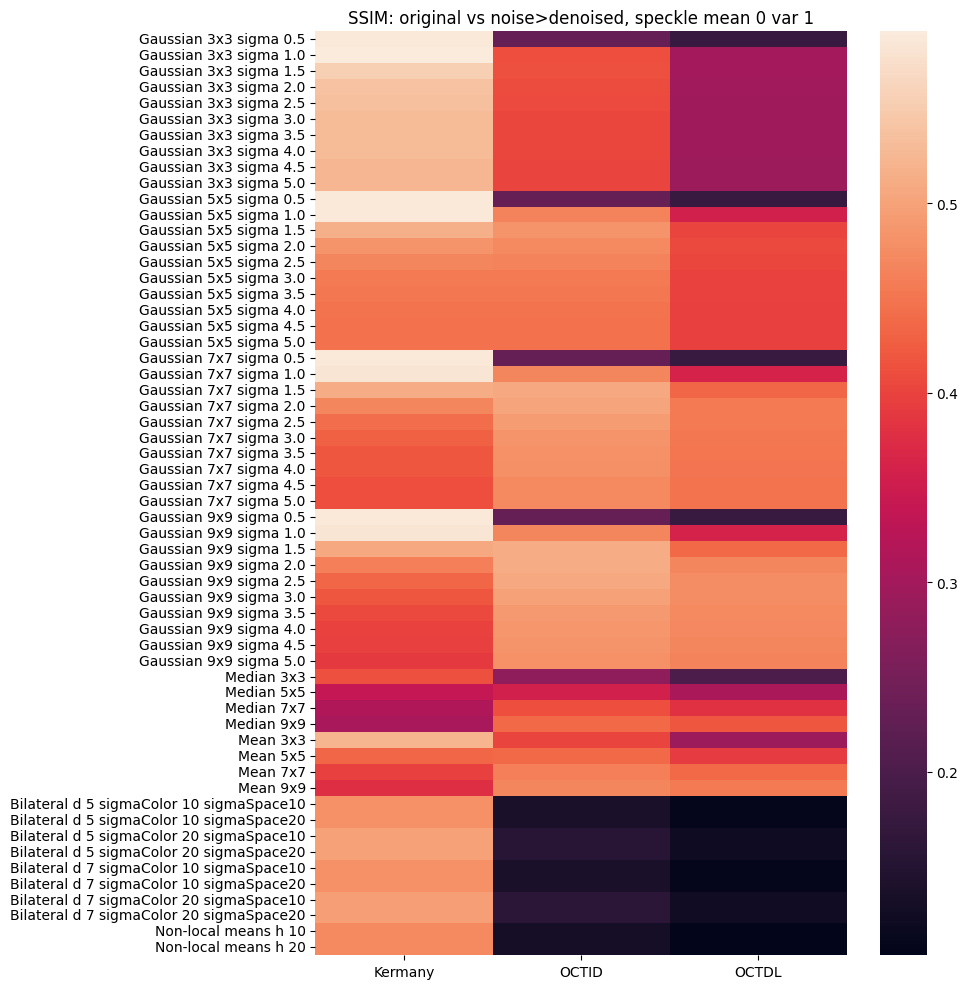

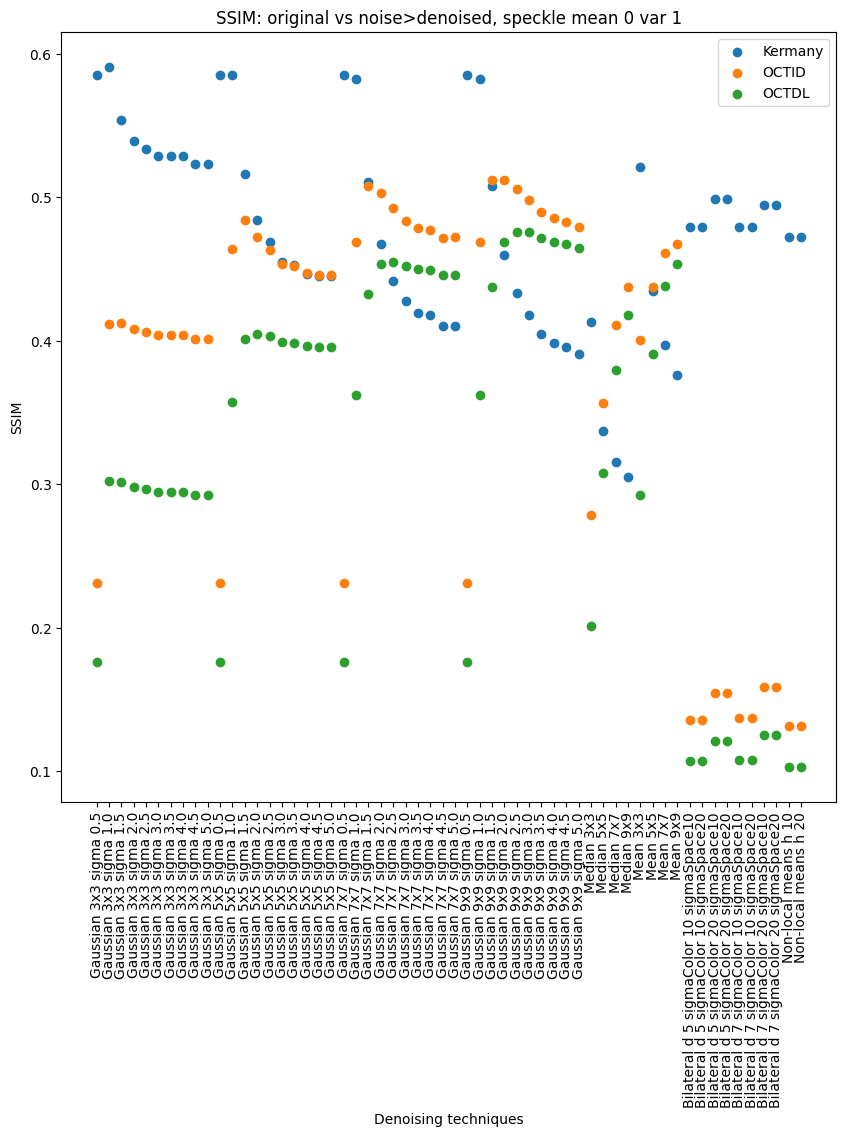

In [129]:
compare_ssims(0,1,kernel_sizes,sigmas,ds,sigmas_color,sigmas_space,hs)